In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.2f}'.format)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [6]:
# Descargar precio del Brent
brent = yf.download("BZ=F", start="2010-01-01", end="2026-12-31")

# Quedarnos solo con el precio de cierre
brent = brent[["Close"]].copy()
brent.columns = ["precio_brent"]

# Ver los primeros registros
print(f"Datos descargados: {len(brent)} observaciones")
print(f"Período: {brent.index[0].date()} al {brent.index[-1].date()}")
brent.head()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 4053 observaciones
Período: 2010-01-04 al 2026-03-30


,precio_brent
Date,
2010-01-04,80.12
2010-01-05,80.59
2010-01-06,81.89
2010-01-07,81.51
2010-01-08,81.37


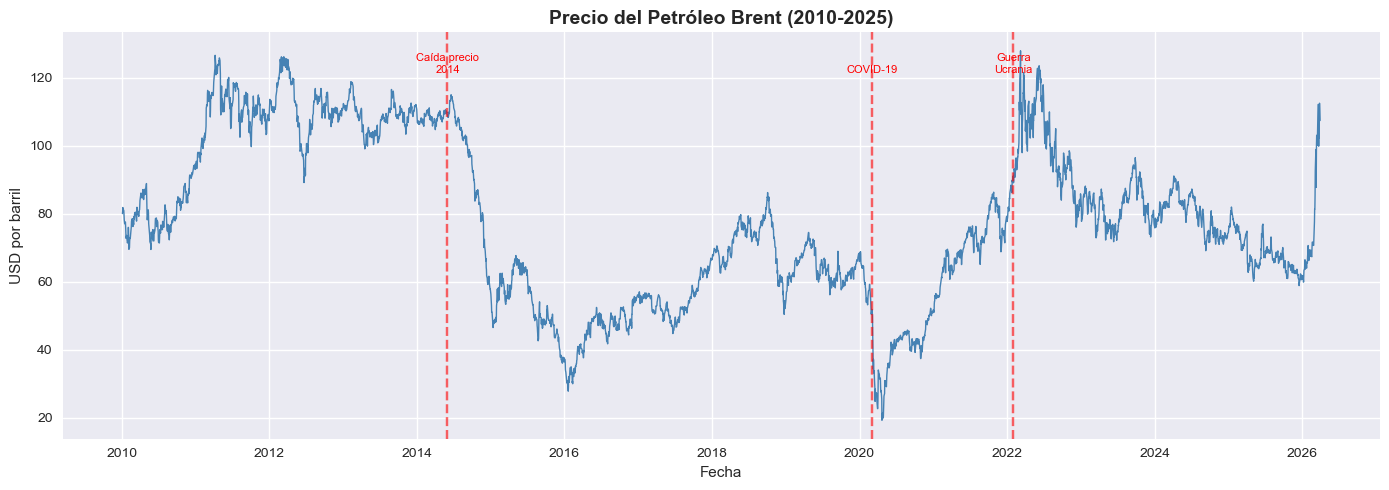

Gráfico guardado en outputs/


In [7]:
# Graficar la serie del Brent
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(brent.index, brent["precio_brent"], color="steelblue", linewidth=1)

ax.set_title("Precio del Petróleo Brent (2010-2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("USD por barril")

# Marcar eventos clave
eventos = {
    "2014-06": "Caída precio\n2014",
    "2020-03": "COVID-19",
    "2022-02": "Guerra\nUcrania"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), brent["precio_brent"].max() * 0.95,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/01_serie_brent.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")

In [8]:
# Descargar tipo de cambio oficial ARS/USD desde la API del BCRA
import requests

url = "https://api.bcra.gob.ar/estadisticas/v3.0/monetarias/1/2010-01-01/2025-12-31"

headers = {"accept": "application/json"}

response = requests.get(url, headers=headers, verify=False)
data = response.json()

# Convertir a DataFrame
tcn = pd.DataFrame(data["results"])
tcn["fecha"] = pd.to_datetime(tcn["fecha"])
tcn = tcn.set_index("fecha")
tcn.columns = ["tipo_cambio"]
tcn["tipo_cambio"] = pd.to_numeric(tcn["tipo_cambio"])
tcn = tcn.sort_index()

print(f"Datos descargados: {len(tcn)} observaciones")
print(f"Período: {tcn.index[0].date()} al {tcn.index[-1].date()}")
tcn.tail()

C:\Users\facun\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.bcra.gob.ar'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [9]:
pip install bcraapi

Note: you may need to restart the kernel to use updated packages.


In [15]:
import requests
import urllib3
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://api.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD"
params = {"fechadesde": "2010-01-01", "fechahasta": "2025-12-31"}

response = requests.get(url, params=params, verify=False)
data = response.json()

# Desanidar usando el campo correcto
registros = []
for item in data["results"]:
    fecha = item["fecha"]
    for detalle in item["detalle"]:
        if detalle["codigoMoneda"] == "USD":
            registros.append({
                "fecha": fecha,
                "tipo_cambio": detalle["tipoCotizacion"]
            })

tcn = pd.DataFrame(registros)
tcn["fecha"] = pd.to_datetime(tcn["fecha"])
tcn = tcn.set_index("fecha")
tcn["tipo_cambio"] = pd.to_numeric(tcn["tipo_cambio"])
tcn = tcn.sort_index()

print(f"Datos descargados: {len(tcn)} observaciones")
print(f"Período: {tcn.index[0].date()} al {tcn.index[-1].date()}")
tcn.tail()

Datos descargados: 1000 observaciones
Período: 2021-11-23 al 2025-12-31


,tipo_cambio
fecha,
2025-12-23,1451.00
2025-12-26,1452.50
2025-12-29,1457.00
2025-12-30,1455.00
2025-12-31,1455.00


In [14]:
# Inspeccionar estructura de un registro
print(data["results"][0])

{'fecha': '2025-12-31', 'detalle': [{'codigoMoneda': 'USD', 'descripcion': 'DOLAR E.E.U.U.', 'tipoPase': 0.0, 'tipoCotizacion': 1455.0}]}


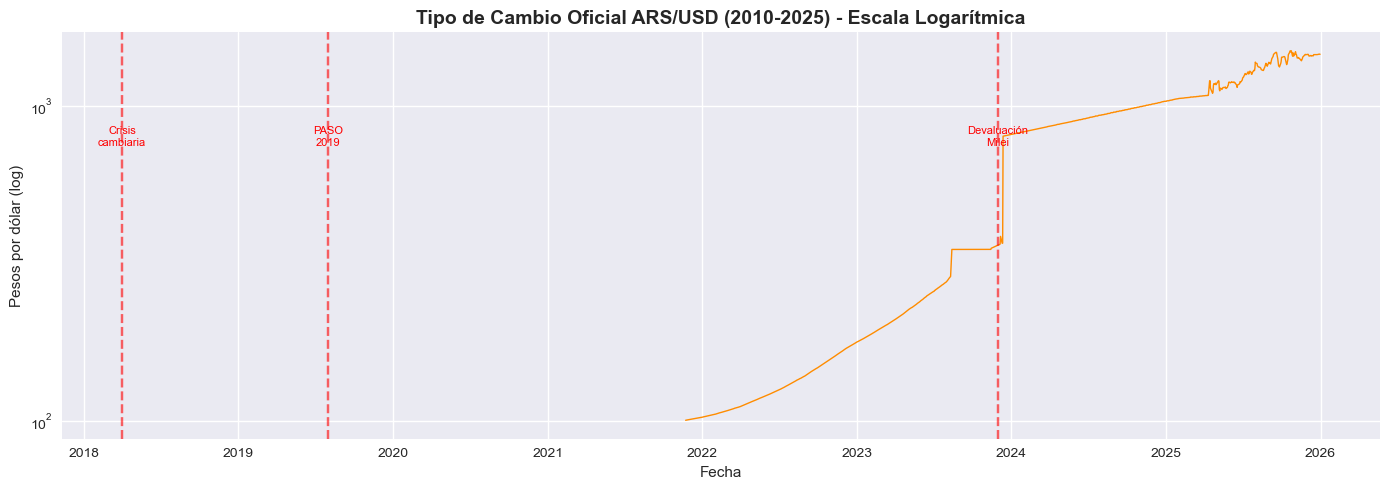

Gráfico guardado en outputs/


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tcn.index, tcn["tipo_cambio"], color="darkorange", linewidth=1)

ax.set_yscale("log")  # Escala logarítmica

ax.set_title("Tipo de Cambio Oficial ARS/USD (2010-2025) - Escala Logarítmica", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pesos por dólar (log)")

# Marcar eventos clave
eventos = {
    "2018-04": "Crisis\ncambiaria",
    "2019-08": "PASO\n2019",
    "2023-12": "Devaluación\nMilei"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), tcn["tipo_cambio"].max() * 0.5,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/02_serie_tipo_cambio.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")

In [19]:
# Descargar tipo de cambio ARS/USD desde yfinance
tcn_historico = yf.download("ARS=X", start="2010-01-01", end="2025-12-31")
tcn_historico = tcn_historico[["Close"]].copy()
tcn_historico.columns = ["tipo_cambio"]
tcn_historico = tcn_historico.sort_index()

print(f"Datos descargados: {len(tcn_historico)} observaciones")
print(f"Período: {tcn_historico.index[0].date()} al {tcn_historico.index[-1].date()}")
tcn_historico.tail()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 4163 observaciones
Período: 2010-01-01 al 2025-12-30


,tipo_cambio
Date,
2025-12-23,1451.72
2025-12-24,1450.16
2025-12-26,1449.58
2025-12-29,1450.50
2025-12-30,1457.01


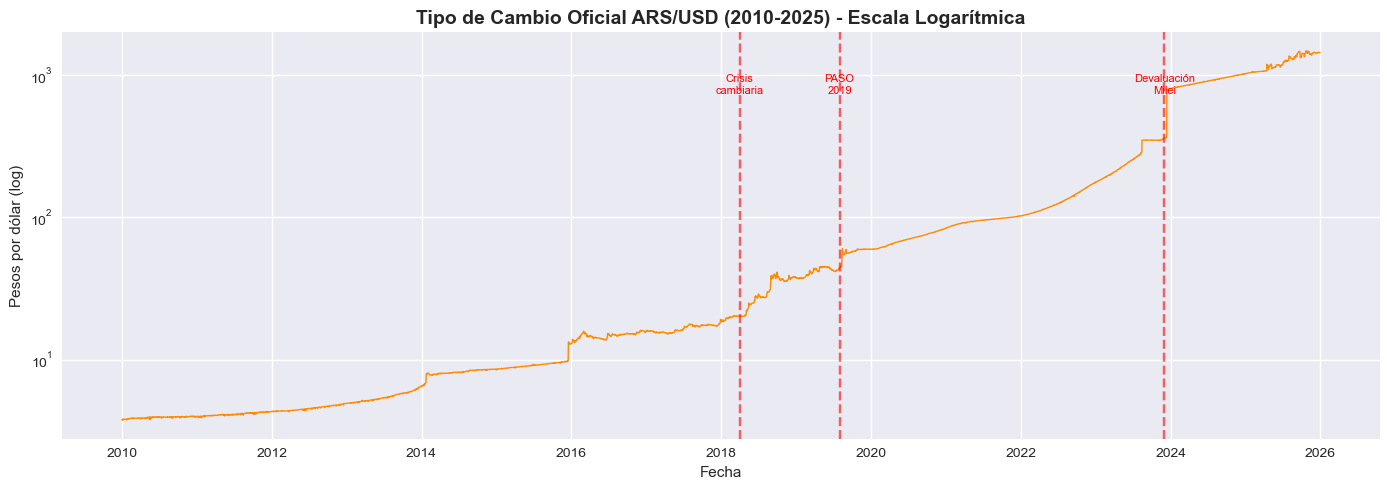

Gráfico guardado en outputs/


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tcn_historico.index, tcn_historico["tipo_cambio"], color="darkorange", linewidth=1)

ax.set_yscale("log")

ax.set_title("Tipo de Cambio Oficial ARS/USD (2010-2025) - Escala Logarítmica", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pesos por dólar (log)")

eventos = {
    "2018-04": "Crisis\ncambiaria",
    "2019-08": "PASO\n2019",
    "2023-12": "Devaluación\nMilei"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), tcn_historico["tipo_cambio"].max() * 0.5,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/02_serie_tipo_cambio.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")

In [23]:
import pdfplumber

# Reemplazá el nombre del archivo por el que descargaste
ruta_pdf = "../data/YPF Investor Presentation Q3 2025 .pdf"

with pdfplumber.open(ruta_pdf) as pdf:
    print(f"Total de páginas: {len(pdf.pages)}")
    print("\n--- PÁGINA 1 ---")
    print(pdf.pages[0].extract_text())

Total de páginas: 25

--- PÁGINA 1 ---
INVESTOR
PRESENTATION
NOVEMBER 2025
Documento: YPF-Privado


In [24]:
import pandas as pd

# Leer la hoja Precios del archivo 2025
precios = pd.read_excel("../data/tabla_2025.xlsx", sheet_name="Precios", header=None)

# Ver las primeras 20 filas
print(precios.head(20))

    0                                            1      2      3      4   \
0  NaN                                          NaN    NaN    NaN    NaN   
1  NaN  Precios promedios de venta (YPF Individual)   1T24   2T24   3T24   
2  NaN                          Cifras no auditadas    NaN    NaN    NaN   
3  NaN                                          NaN    NaN    NaN    NaN   
4  NaN                                     Upstream    NaN    NaN    NaN   
5  NaN                      Precios internacionales    NaN    NaN    NaN   
6  NaN                        Crudo Brent (US$/bbl)  81.84  85.00  78.54   
7  NaN                        Henry Hub (US$/Mmbtu)   2.11   2.33   2.23   
8  NaN                                          NaN    NaN    NaN    NaN   
9  NaN                 Precios de realización local    NaN    NaN    NaN   
10 NaN                        Crudo local (US$/bbl)  68.31  70.80  68.26   
11 NaN                      Gas Natural (US$/Mmbtu)   2.96   3.99   4.46   
12 NaN      

In [25]:
# Leer hoja Precios
precios_raw = pd.read_excel("../data/tabla_2025.xlsx", sheet_name="Precios", header=None)

# Extraer trimestres y precios
trimestres = precios_raw.iloc[1, 2:11].tolist()
brent_ypf = precios_raw.iloc[6, 2:11].tolist()
crudo_local = precios_raw.iloc[10, 2:11].tolist()

# Armar DataFrame
precios_ypf = pd.DataFrame({
    "trimestre": trimestres,
    "brent_referencia": brent_ypf,
    "precio_local": crudo_local
})

print(precios_ypf)

  trimestre  brent_referencia  precio_local
0      1T24             81.84         68.31
1      2T24             85.00         70.80
2      3T24             78.54         68.26
3      4T24             73.97         65.65
4   2024.00             79.84         68.20
5      1T25             74.92         67.88
6      2T25             66.76         59.49
7      3T25             68.13         60.01
8      4T25             63.08         53.03


In [27]:
# Leer hoja Precios del archivo 2023
precios_raw_23 = pd.read_excel("../data/tabla_2023.xlsx", sheet_name="Precios", header=None)

# Ver primeras 20 filas para confirmar que la estructura es igual
print(precios_raw_23.head(20))

    0                                 1      2      3      4      5   \
0  NaN                               NaN    NaN    NaN    NaN    NaN   
1  NaN                               NaN    NaN    NaN    NaN    NaN   
2  NaN                (Volver al Indice)    NaN    NaN    NaN    NaN   
3  NaN                               NaN    NaN    NaN    NaN    NaN   
4  NaN  Precios promedios de realización   1T22   2T22   3T22   4T22   
5  NaN               Cifras no auditadas    NaN    NaN    NaN    NaN   
6  NaN                               NaN    NaN    NaN    NaN    NaN   
7  NaN                          Upstream    NaN    NaN    NaN    NaN   
8  NaN           Precios internacionales    NaN    NaN    NaN    NaN   
9  NaN             Crudo Brent (US$/bbl)  97.38 111.89  97.81  88.63   
10 NaN             Henry Hub (US$/Mmbtu)   4.58   7.51   7.93   5.04   
11 NaN                               NaN    NaN    NaN    NaN    NaN   
12 NaN      Precios de realización local    NaN    NaN    NaN   

In [28]:
# Leer hoja Precios del archivo 2023
precios_raw_23 = pd.read_excel("../data/tabla_2023.xlsx", sheet_name="Precios", header=None)

# Extraer trimestres y precios
trimestres_23 = precios_raw_23.iloc[4, 2:].tolist()
brent_23 = precios_raw_23.iloc[9, 2:].tolist()
crudo_local_23 = precios_raw_23.iloc[13, 2:].tolist()

# Armar DataFrame
precios_23 = pd.DataFrame({
    "trimestre": trimestres_23,
    "brent_referencia": brent_23,
    "precio_local": crudo_local_23
})

# Eliminar filas con NaN
precios_23 = precios_23.dropna()

print(precios_23)

  trimestre  brent_referencia  precio_local
0      1T22             97.38         58.89
1      2T22            111.89         65.13
2      3T22             97.81         67.45
3      4T22             88.63         66.30
4  12M 2022             98.93         64.45
5      1T23             82.23         66.90
6      2T23             78.04         63.38
7      3T23             85.92         60.65
8      4T23             82.70         59.33
9  12M 2023             82.20         62.50


In [29]:
precios_raw_24 = pd.read_excel("../data/tabla_2024.xlsx", sheet_name="Precios", header=None)
print(precios_raw_24.head(12))

    0                                                  1     2     3     4   \
0  NaN                                                NaN   NaN   NaN   NaN   
1  NaN  Precios promedios de realización (YPF Individual)  1T23  2T23  3T23   
2  NaN                                Cifras no auditadas   NaN   NaN   NaN   
3  NaN                                                NaN   NaN   NaN   NaN   
4  NaN                                           Upstream   NaN   NaN   NaN   
5  NaN                            Precios internacionales   NaN   NaN   NaN   
6  NaN                              Crudo Brent (US$/bbl) 82.23 78.04 85.92   
7  NaN                              Henry Hub (US$/Mmbtu)  2.77  2.32  2.66   
8  NaN                                                NaN   NaN   NaN   NaN   
9  NaN                       Precios de realización local   NaN   NaN   NaN   
10 NaN                              Crudo local (US$/bbl) 66.90 63.38 60.65   
11 NaN                            Gas Natural (US$/M

In [30]:
precios_raw_24 = pd.read_excel("../data/tabla_2024.xlsx", sheet_name="Precios", header=None)

trimestres_24 = precios_raw_24.iloc[1, 2:].tolist()
brent_24 = precios_raw_24.iloc[6, 2:].tolist()
crudo_local_24 = precios_raw_24.iloc[10, 2:].tolist()

precios_24 = pd.DataFrame({
    "trimestre": trimestres_24,
    "brent_referencia": brent_24,
    "precio_local": crudo_local_24
})

precios_24 = precios_24.dropna()
print(precios_24)

  trimestre  brent_referencia  precio_local
0      1T23             82.23         66.90
1      2T23             78.04         63.38
2      3T23             85.92         60.65
3      4T23             82.70         59.33
4   2023.00             82.20         62.50
5      1T24             81.84         68.31
6      2T24             85.00         70.80
7      3T24             78.54         68.26
8      4T24             73.97         65.65
9   2024.00             79.84         68.20


In [31]:
# Quedarnos solo con trimestres (excluir filas anuales como 2023.00, 2024.00, 12M 2022)
trimestres_validos = ["1T22", "2T22", "3T22", "4T22",
                      "1T23", "2T23", "3T23", "4T23",
                      "1T24", "2T24", "3T24", "4T24",
                      "1T25", "2T25", "3T25", "4T25"]

# Combinar los tres DataFrames
precios_total = pd.concat([precios_23, precios_24, precios_ypf])

# Filtrar solo trimestres válidos y eliminar duplicados
precios_total = precios_total[precios_total["trimestre"].isin(trimestres_validos)]
precios_total = precios_total.drop_duplicates(subset="trimestre")

# Ordenar
precios_total = precios_total.set_index("trimestre")
precios_total = precios_total.loc[trimestres_validos]

print(precios_total)
print(f"\nTotal trimestres: {len(precios_total)}")

           brent_referencia  precio_local
trimestre                                
1T22                  97.38         58.89
2T22                 111.89         65.13
3T22                  97.81         67.45
4T22                  88.63         66.30
1T23                  82.23         66.90
2T23                  78.04         63.38
3T23                  85.92         60.65
4T23                  82.70         59.33
1T24                  81.84         68.31
2T24                  85.00         70.80
3T24                  78.54         68.26
4T24                  73.97         65.65
1T25                  74.92         67.88
2T25                  66.76         59.49
3T25                  68.13         60.01
4T25                  63.08         53.03

Total trimestres: 16


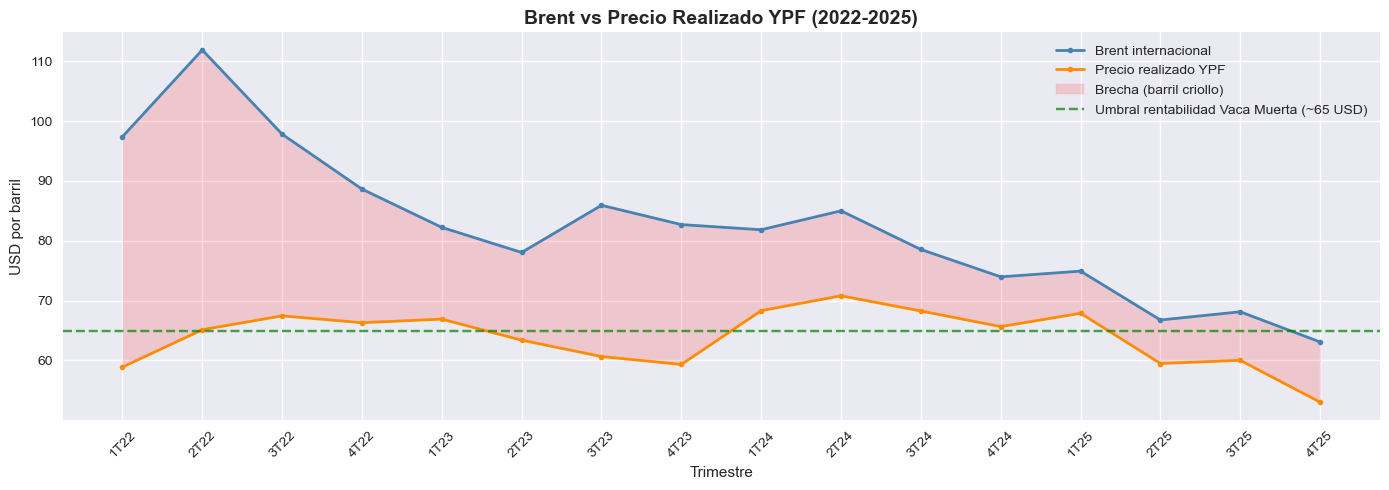

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(precios_total.index, precios_total["brent_referencia"], 
        color="steelblue", linewidth=2, marker="o", markersize=4, label="Brent internacional")
ax.plot(precios_total.index, precios_total["precio_local"], 
        color="darkorange", linewidth=2, marker="o", markersize=4, label="Precio realizado YPF")

ax.fill_between(precios_total.index, 
                precios_total["precio_local"], 
                precios_total["brent_referencia"],
                alpha=0.15, color="red", label="Brecha (barril criollo)")

ax.axhline(y=65, color="green", linestyle="--", alpha=0.7, label="Umbral rentabilidad Vaca Muerta (~65 USD)")

ax.set_title("Brent vs Precio Realizado YPF (2022-2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Trimestre")
ax.set_ylabel("USD por barril")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/03_brent_vs_precio_local.png", dpi=150)
plt.show()